# datetime 열과 groupby로 히스토그램 그리기

이 노트북은 `pandas`로 날씨 데이터를 불러오고, `일시` 열을 `datetime` 형식으로 바꾼 뒤,  
그 안에서 **월 정보만 따로 새로운 열로 추가**하여 히스토그램과 막대그래프를 그리기.

1. `weather.csv` 파일을 불러와 DataFrame을 확인함.
2. `일시` 열을 `datetime` 형식으로 변환함.
3. `일시`에서 월 정보를 꺼내 `월` 열로 추가함.
4. 특정 월만 골라 히스토그램을 그림.
5. `groupby()`로 월별 통계를 계산하고 시각화함.


## 1. 라이브러리 불러오기와 데이터 로드


1. `pandas`와 `matplotlib.pyplot`을 불러옴.
2. `weather.csv` 파일을 읽어 DataFrame으로 저장함.
3. 앞부분 5행과 열 이름을 확인함.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

path = 'https://github.com/dongupak/DataML/raw/main/csv/'
weather_file = path + 'weather.csv'
weather = pd.read_csv(weather_file, encoding='CP949') # 한글로 인코딩
weather.head()

,일시,평균기온,최대풍속,평균풍속
0,2010-08-01,28.7,8.3,3.4
1,2010-08-02,25.2,8.7,3.8
2,2010-08-03,22.1,6.3,2.9
3,2010-08-04,25.3,6.6,4.2
4,2010-08-05,27.2,9.1,5.6


## 2. 일시 열을 datetime으로 바꾸고 월 열 추가하기

`일시` 열을 `datetime` 형식으로 바꾼 뒤, 그 안의 **월(month)** 정보만 꺼내서  
새로운 `월` 열로 저장함.

예) `2020-07-15`라는 날짜가 있으면, 여기서 `7`만 뽑아 `월` 열에 기입


In [4]:
# TODO 1: '일시' 열을 datetime 형식으로 변환함.
# 힌트: pd.DatetimeIndex() 사용
weather['Month']=pd.DatetimeIndex(weather['일시']).month
weather
# TODO 2: '일시' 열의 자료형과 앞부분 데이터를 확인함.
weather['일시'].describe()
weather.head()

,일시,평균기온,최대풍속,평균풍속,Month
0,2010-08-01,28.7,8.3,3.4,8
1,2010-08-02,25.2,8.7,3.8,8
2,2010-08-03,22.1,6.3,2.9,8
3,2010-08-04,25.3,6.6,4.2,8
4,2010-08-05,27.2,9.1,5.6,8


## 3. 특정 월 추출과 히스토그램

이제 `월` 열을 이용해 특정 월의 데이터만 골라낼 수 있음.  
먼저 `7월` 데이터만 추출한 뒤, `평균기온` 분포를 히스토그램으로 그려봄.


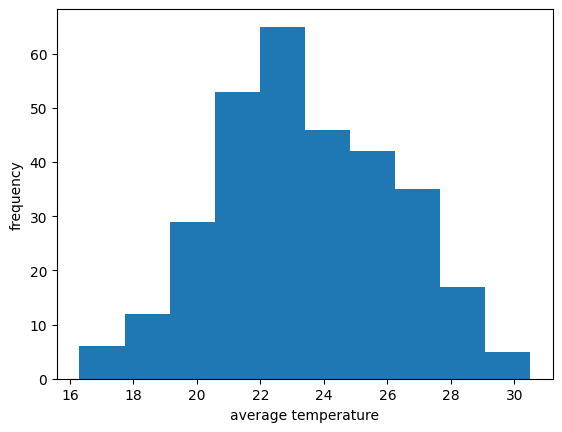

In [21]:
from matplotlib.pyplot import hist

# TODO 1: 7월 데이터만 추출해 july에 저장함.
july = weather[weather['month'] == 7]
july
# TODO 2: july의 앞부분과 행 개수를 확인함.
july.head()
len(july)

# TODO 3: july의 '평균기온' 히스토그램을 그림.
plt.hist(july['평균기온'], bins = 10)
plt.xlabel("average temperature")
plt.ylabel("frequency")
#plt.legend()
plt.show()

## 4. 두 개의 월 비교하기

이번에는 `1월`과 `8월`의 `평균풍속` 분포를  
한 그림에 겹쳐서 비교해봄.

히스토그램 두 개를 한 그래프에 그리면  
계절에 따라 값의 분포가 어떻게 달라지는지 한눈에 볼 수 있음.


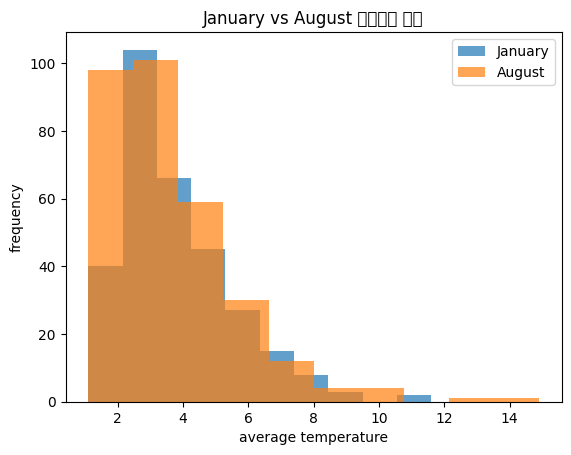

In [22]:
# TODO 1: 1월 데이터를 jan에 저장함.
January = weather[weather['month'] == 1]
# TODO 2: 8월 데이터를 aug에 저장함.
August = weather[weather['month'] == 8]
# TODO 3: jan과 aug의 '평균풍속' 히스토그램을 한 그림에 겹쳐 그림.
plt.hist(January['평균풍속'], label='January', alpha=0.7)
plt.hist(August['평균풍속'], label='August', alpha=0.7)

plt.title('January vs August 평균풍속 분포')
plt.xlabel("average temperature")
plt.ylabel("frequency")
plt.legend()

plt.show()


## 5. 월별 평균기온 변화를 꺾은선그래프로 그리기

월별 평균기온의 평균을 구해서 꺾은선그래프로 그려봄.
for문을 사용해서 그림.

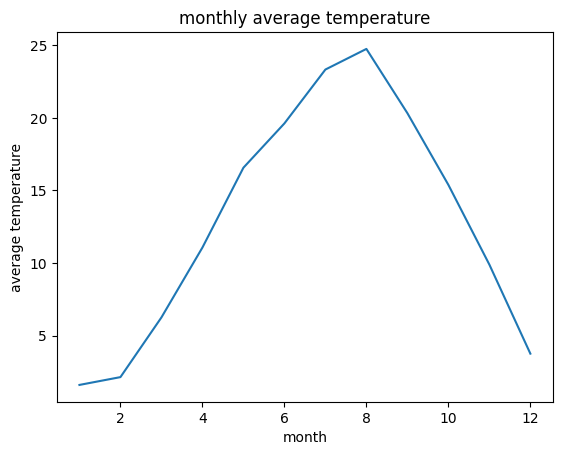

In [40]:
import numpy as np
import matplotlib.pyplot as plt

monthly = [None for x in range(12)]
monthly_temp = [0 for x in range(12)]

# TODO 1: for문을 사용해서 월별 평균 기온 계산
for i in range(1, 13):
    table = weather[weather['month'] == i]
    monthly_temp[i-1] = table['평균기온'].mean()

# TODO 2: plt.plot 이용해서 월별 평균 기온 출력하기
months = np.arange(1, 13)  # 1~12월

plt.plot(months, monthly_temp)

plt.title('monthly average temperature')
plt.xlabel("month")
plt.ylabel("average temperature")
plt.xticks(months)

plt.show()

## 6. groupby로 월별 통계 구하기

이제 `월` 열을 기준으로 데이터를 묶어봄.  
`groupby("월")`를 사용하면 같은 월끼리 데이터를 모아  
평균, 최솟값, 최댓값, 개수 등을 계산할 수 있음.


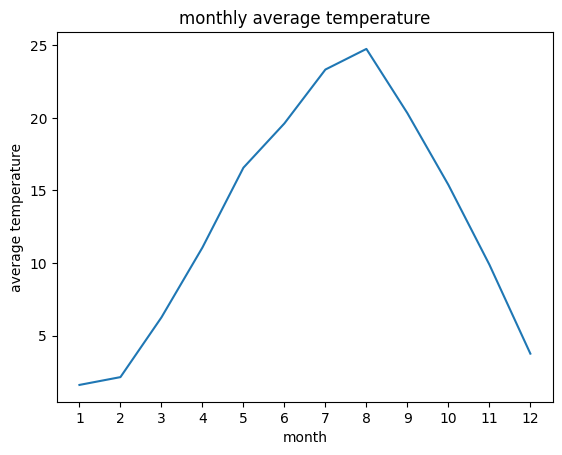

In [55]:
import matplotlib.pyplot as plt

# TODO 1: 월별 평균기온 평균을 계산해 monthly_temp_mean에 저장함.
monthly_temp_mean = [0 for x in range(12)]
for i in range(1, 13):
    monthly_temp_mean[i-1] = (weather.groupby("Month").get_group(i)['평균기온']).mean()

# TODO 2: 월별 평균기온 그래프를 그림
# 제목, x축 라벨, y축 라벨을 추가함.
plt.plot(range(1, 13), monthly_temp_mean)
plt.title('monthly average temperature')
plt.xlabel("month")
plt.ylabel("average temperature")
plt.xticks(range(1, 13))
plt.show()

## 6. groupby 객체에서 특정 월 다시 꺼내기

`groupby("월")` 결과를 객체로 저장한 뒤 `get_group()`을 쓰면  
원하는 월의 데이터만 다시 꺼낼 수 있음.

이번에는 `3월`과 `10월` 데이터를 다시 꺼내어  
각 월의 `최대풍속` 히스토그램을 비교해봄.


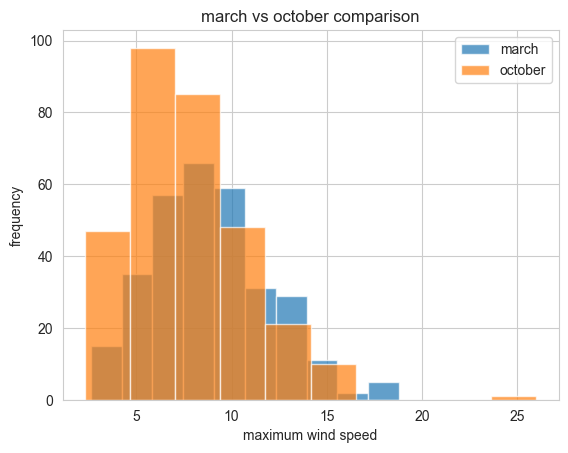

In [5]:
# TODO 1: '월' 열을 기준으로 groupby 객체를 만듦.
weather['Month'] = pd.DatetimeIndex(weather["일시"]).month
# TODO 2: 3월 데이터를 march에 저장함.
# TODO 3: 10월 데이터를 october에 저장함.
# 힌트: get_group() 사용
march = weather.groupby("Month").get_group(3)
october = weather.groupby("Month").get_group(10)
weather.groupby("Month").mean(numeric_only=True)
# TODO 4: march와 october의 '최대풍속' 히스토그램을 한 그림에 겹쳐 그림.
# 제목, 축 이름, 범례를 추가함.
plt.hist(march['최대풍속'], label='march', alpha=0.7)
plt.hist(october['최대풍속'], label='october', alpha=0.7)

plt.title('march vs october comparison')
plt.xlabel("maximum wind speed")
plt.ylabel("frequency")
plt.legend()

plt.show()
